<a href="https://colab.research.google.com/github/surayaqis/DataManagement/blob/Assignment2/STQD6324_Assignment2_P166248.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# STQD6324 Data Management - Assignment 2

# P166248 - Suraya Balqis binti Ab.Ghafar

# MovieLens 100k — Spark + Cassandra Pipeline with HDFS

This notebook runs **its own single-node HDFS** inside the Colab VM, so the dataset
is genuinely loaded into HDFS (`hdfs dfs -put`) and Spark reads it back over
`hdfs://`. It is fully self-contained: it installs Hadoop, Spark and Cassandra, and downloads the data itself, so it runs end-to-end with **Runtime → Run all** on any Colab session.


**Versions:** Python 3 (Colab), Hadoop 3.3.6 (single-node HDFS), Spark 3.5.1,
Cassandra 4.1.x, spark-cassandra-connector 3.5.1.

> The setup cells (1–4) take a few minutes the first time.

## Setup 1 — Install Java, Spark and the Cassandra driver

In [46]:
!apt-get -qq install openjdk-11-jdk-headless pigz > /dev/null
!pip install -q --no-warn-conflicts pyspark==3.5.1 cassandra-driver
import os, subprocess
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"
print("Java + PySpark ready")

Java + PySpark ready


## Setup 1b — Fast downloads (mirror + optional cache)

`fast_get` pulls each large file from a fast Apache mirror, falling back to the
(slower) archive server if the mirror doesn't have it, and reuses a Google Drive
copy when caching is on. **Caching is optional** — to enable it for repeated
testing, run the *Enable Drive caching* cell below; otherwise downloads happen
fresh each session with no sign-in needed.

In [47]:
CACHE_DIR = None   # set by the optional Drive cell below; None = download fresh

def fast_get(filename, urls):
    if CACHE_DIR:
        hit = os.path.join(CACHE_DIR, filename)
        if os.path.exists(hit):
            subprocess.run(["cp", hit, filename], check=True)
            print("from cache:", filename); return
    for u in urls:
        rc = subprocess.run(["wget", "-q", "--tries=2", "-O", filename, u]).returncode
        if rc == 0 and os.path.exists(filename) and os.path.getsize(filename) > 1000:
            print("downloaded from", u); break
    else:
        raise RuntimeError("all mirrors failed for " + filename)
    if CACHE_DIR:
        os.makedirs(CACHE_DIR, exist_ok=True)
        subprocess.run(["cp", filename, os.path.join(CACHE_DIR, filename)], check=True)
        print("cached for next run")
print("fast_get ready")

fast_get ready


### (Optional) Enable Drive caching — run only if testing repeatedly
Saves the big tarballs to Google Drive so later runs skip the downloads. It asks
you to sign in to Drive. Skip it for a clean one-click run.

In [48]:
from google.colab import drive
drive.mount("/content/drive")
CACHE_DIR = "/content/drive/MyDrive/colab_cache"
os.makedirs(CACHE_DIR, exist_ok=True)
print("caching enabled at", CACHE_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
caching enabled at /content/drive/MyDrive/colab_cache


## Setup 2 — Install and start a single-node HDFS (Hadoop)

We install Hadoop, point it at `hdfs://localhost:9000`, format the namenode, and
start the namenode and datanode directly (no SSH needed).

In [49]:
fast_get("hadoop-3.3.6.tar.gz", [
    "https://dlcdn.apache.org/hadoop/common/hadoop-3.3.6/hadoop-3.3.6.tar.gz",
    "https://archive.apache.org/dist/hadoop/common/hadoop-3.3.6/hadoop-3.3.6.tar.gz"])
!tar -I pigz -xf hadoop-3.3.6.tar.gz

os.environ["HADOOP_HOME"] = os.path.abspath("hadoop-3.3.6")
os.environ["PATH"] = os.environ["HADOOP_HOME"] + "/bin:" + os.environ["PATH"]
HADOOP = os.environ["HADOOP_HOME"]

core = '''<configuration>
  <property><name>fs.defaultFS</name><value>hdfs://localhost:9000</value></property>
</configuration>'''
hdfs = '''<configuration>
  <property><name>dfs.replication</name><value>1</value></property>
  <property><name>dfs.namenode.name.dir</name><value>/content/hdfs/name</value></property>
  <property><name>dfs.datanode.data.dir</name><value>/content/hdfs/data</value></property>
</configuration>'''
open(HADOOP + "/etc/hadoop/core-site.xml", "w").write(core)
open(HADOOP + "/etc/hadoop/hdfs-site.xml", "w").write(hdfs)
with open(HADOOP + "/etc/hadoop/hadoop-env.sh", "a") as f:
    f.write("\nexport JAVA_HOME=" + os.environ["JAVA_HOME"] + "\n")
    f.write("export HDFS_NAMENODE_USER=root\n")
    f.write("export HDFS_DATANODE_USER=root\n")
    f.write("export HDFS_SECONDARYNAMENODE_USER=root\n")
print("Hadoop configured at", HADOOP)

from cache: hadoop-3.3.6.tar.gz
Hadoop configured at /content/hadoop-3.3.6


In [50]:
import time
# format namenode (first run only) and start the daemons
!echo "Y" | $HADOOP_HOME/bin/hdfs namenode -format -force > /dev/null 2>&1
!$HADOOP_HOME/bin/hdfs --daemon start namenode
!$HADOOP_HOME/bin/hdfs --daemon start datanode
time.sleep(12)
!$HADOOP_HOME/bin/hdfs dfsadmin -safemode leave
!$HADOOP_HOME/bin/hdfs dfsadmin -report | head -12

namenode is running as process 9720.  Stop it first and ensure /tmp/hadoop-root-namenode.pid file is empty before retry.
datanode is running as process 9782.  Stop it first and ensure /tmp/hadoop-root-datanode.pid file is empty before retry.
Safe mode is OFF
Configured Capacity: 115658190848 (107.72 GB)
Present Capacity: 88335392768 (82.27 GB)
DFS Remaining: 88333086720 (82.27 GB)
DFS Used: 2306048 (2.20 MB)
DFS Used%: 0.00%
Replicated Blocks:
	Under replicated blocks: 0
	Blocks with corrupt replicas: 0
	Missing blocks: 0
	Missing blocks (with replication factor 1): 0
	Low redundancy blocks with highest priority to recover: 0
	Pending deletion blocks: 0


## Setup 4 — Download and start Cassandra

In [51]:
fast_get("apache-cassandra-4.1.4-bin.tar.gz", [
    "https://dlcdn.apache.org/cassandra/4.1.4/apache-cassandra-4.1.4-bin.tar.gz",
    "https://archive.apache.org/dist/cassandra/4.1.4/apache-cassandra-4.1.4-bin.tar.gz"])
!tar -I pigz -xf apache-cassandra-4.1.4-bin.tar.gz
CASS = "apache-cassandra-4.1.4/bin"
subprocess.Popen([CASS + "/cassandra", "-R"],
                 stdout=open("cass.log", "w"), stderr=subprocess.STDOUT)
for _ in range(40):
    out = subprocess.run([CASS + "/nodetool", "status"], capture_output=True, text=True)
    if "UN" in out.stdout:
        print("Cassandra is UP (UN)"); break
    time.sleep(5)
else:
    print("not up yet — check cass.log"); print(open("cass.log").read()[-800:])

from cache: apache-cassandra-4.1.4-bin.tar.gz
Cassandra is UP (UN)


## 1.0 Import libraries for Apache Spark and Cassandra integration

In [52]:
from pyspark.sql import SparkSession, Window
from pyspark.sql import functions as F
from pyspark.sql.types import StructType, StructField, IntegerType, StringType
from cassandra.cluster import Cluster
import pandas as pd
import matplotlib.pyplot as plt

CONNECTOR = "com.datastax.spark:spark-cassandra-connector_2.12:3.5.1"
spark = (SparkSession.builder.appName("MovieLens100k_HDFS_Cassandra")
         .config("spark.jars.packages", CONNECTOR)
         .config("spark.cassandra.connection.host", "127.0.0.1")
         .config("spark.hadoop.fs.defaultFS", "hdfs://localhost:9000")
         .master("local[*]").getOrCreate())
sc = spark.sparkContext
print("Spark version:", spark.version)

Spark version: 3.5.1


## 2.0 — Download the dataset MovieLens and load it into HDFS

In [53]:
# Download the MovieLens 100k dataset from GroupLens and unzip it.
!wget -q https://files.grouplens.org/datasets/movielens/ml-100k.zip
!unzip -q -o ml-100k.zip

# Create a directory in HDFS for the MovieLens 100k dataset.
# The '$HADOOP_HOME/bin/hdfs' prefix executes HDFS commands.
# '-mkdir -p' creates the directory if it doesn't exist.
!$HADOOP_HOME/bin/hdfs dfs -mkdir -p /user/maria_dev/ml-100k

# Upload the unzipped data files (u.data, u.item, u.user) into the HDFS directory.
# '-put -f' forces the overwrite if files already exist.
!$HADOOP_HOME/bin/hdfs dfs -put -f ml-100k/u.data ml-100k/u.item ml-100k/u.user /user/maria_dev/ml-100k/

# Print a message indicating that files are now in HDFS.
print("---- files now in HDFS: ----")

# List the contents of the HDFS directory to verify the upload.
# '-ls' lists the files and directories.
!$HADOOP_HOME/bin/hdfs dfs -ls /user/maria_dev/ml-100k

---- files now in HDFS: ----
Found 3 items
-rw-r--r--   1 root supergroup    1979173 2026-06-25 16:48 /user/maria_dev/ml-100k/u.data
-rw-r--r--   1 root supergroup     236344 2026-06-25 16:48 /user/maria_dev/ml-100k/u.item
-rw-r--r--   1 root supergroup      22628 2026-06-25 16:48 /user/maria_dev/ml-100k/u.user


## 2.1 Read the files from HDFS

In [54]:
HDFS_DIR = "hdfs://localhost:9000/user/maria_dev/ml-100k"
DATA_PATH = HDFS_DIR + "/u.data"
ITEM_PATH = HDFS_DIR + "/u.item"
USER_PATH = HDFS_DIR + "/u.user"
print(sc.textFile(DATA_PATH).take(2))   # reading straight from HDFS

['196\t242\t3\t881250949', '186\t302\t3\t891717742']


## 3.0 Load raw data from HDFS file into Spark RDDs

In [55]:
raw_ratings = sc.textFile(DATA_PATH)  #movie ratings
raw_items   = sc.textFile(ITEM_PATH)  #movie information
raw_users   = sc.textFile(USER_PATH)  #user information
print(raw_ratings.first()); print(raw_items.first());print(raw_users.first())

196	242	3	881250949
1|Toy Story (1995)|01-Jan-1995||http://us.imdb.com/M/title-exact?Toy%20Story%20(1995)|0|0|0|1|1|1|0|0|0|0|0|0|0|0|0|0|0|0|0
1|24|M|technician|85711


## 4.0 Transform RDDs into Spark DataFrames
## 5.0 Data Cleaning & Preprocessing

This is to transform the raw RDDs (raw_ratings, raw_users, raw_items) that were loaded from HDFS into structured Spark DataFrames (ratings_df, users_df, items_df). It involves parsing each line of the raw text data and defining a schema for each DataFrame.

In [56]:
# to process each line of raw ratings data, to create a Spark DataFrame called ratings_df
# u=user ID, i=item ID, r=rating, ts=time stamp
def parse_rating(line):
    u, i, r, ts = line.split("\t"); return (int(u), int(i), int(r), int(ts))
ratings_df = spark.createDataFrame(raw_ratings.map(parse_rating),
    StructType([StructField("user_id",IntegerType()),StructField("item_id",IntegerType()),
                StructField("rating",IntegerType()),StructField("ts",IntegerType())])
    ).dropDuplicates(["user_id","item_id"])

# duplicates of user_id and item_ide are removed to ensure there are no
# duplicate entries for same user rating the same item.

In [57]:
# to process each line of raw user data, to create a Spark DataFrame called ratings_df
# uid=user ID, age=age, g=gender, occ=occupation, z=zip code
def parse_user(line):
    uid,age,g,occ,z = line.split("|"); return (int(uid),int(age),g,occ,z)
users_df = spark.createDataFrame(raw_users.map(parse_user),
    StructType([StructField("user_id",IntegerType()),StructField("age",IntegerType()),
                StructField("gender",StringType()),StructField("occupation",StringType()),
                StructField("zip",StringType())]))

#specifies five columns with correct data types

In [58]:
GENRES = ["unknown","Action","Adventure","Animation","Children","Comedy","Crime",
          "Documentary","Drama","Fantasy","Film-Noir","Horror","Musical","Mystery",
          "Romance","Sci-Fi","Thriller","War","Western"]
#this list defines 19 possible genres for movies

def parse_item(line):
    p = line.split("|"); return tuple([int(p[0]), p[1]] + [int(x) for x in p[5:24]])
item_fields = [StructField("movie_id",IntegerType()),StructField("title",StringType())] + \
              [StructField("g_"+g, IntegerType()) for g in GENRES]
items_df = spark.createDataFrame(raw_items.map(parse_item), StructType(item_fields))

#p[0] = movie ID, p[1]=title, p[5]-p[24]= binary indicators for each of the 19 genres
# return tuple, to the correct data type


#to verify all data has been loaded correctly
print("ratings:",ratings_df.count(),"| users:",users_df.count(),"| movies:",items_df.count())


ratings: 100000 | users: 943 | movies: 1682


## 6.0 Register Spark SQL views

Register dataframes as a temporary SQL view

In [59]:
ratings_df.createOrReplaceTempView("ratings")
users_df.createOrReplaceTempView("users")
items_df.createOrReplaceTempView("items")
print("views ready")

views ready


## 6.0 Cassandra — create keyspace and tables

In [60]:
# establish connection to Cassandra cluster
session = Cluster(["127.0.0.1"]).connect()

# creates a new Cassandra keyspace named movielens if it's not exist yet
# keyspace in Cassandra is similar to a schema or database (relational databses)
# SimpleStrategy is used for single-datacenter deployments (like single-node setup),
# replication_factor:1 means that each piece of data will have one copy.
session.execute("CREATE KEYSPACE IF NOT EXISTS movielens WITH replication={'class':'SimpleStrategy','replication_factor':1}")

# sets movielens as active keyspace for all subsequent commands
session.set_keyspace("movielens")
for q in [
 "CREATE TABLE IF NOT EXISTS movie_avg_ratings (movie_id int PRIMARY KEY, title text, avg_rating double, num_ratings int)",
 "CREATE TABLE IF NOT EXISTS top_ten_movies (rank int PRIMARY KEY, movie_id int, title text, avg_rating double, num_ratings int)",
 "CREATE TABLE IF NOT EXISTS user_fav_genre (user_id int PRIMARY KEY, num_ratings int, favourite_genre text)",
 "CREATE TABLE IF NOT EXISTS young_users (user_id int PRIMARY KEY, age int, gender text, occupation text)",
 "CREATE TABLE IF NOT EXISTS scientists_30_40 (user_id int PRIMARY KEY, age int, gender text, occupation text)"]:
    session.execute(q)

## Task (i) — Average rating per movie  *(Spark SQL)*

In [61]:
# Top 10 most-rated movies - average rating per movie, sorted by No. of ratings per movie
movie_avg = spark.sql("SELECT i.movie_id, i.title, ROUND(AVG(r.rating),2) AS avg_rating, COUNT(*) AS num_ratings "
                      "FROM ratings r JOIN items i ON r.item_id=i.movie_id GROUP BY i.movie_id, i.title")
print("movies rated:", movie_avg.count())
movie_avg.orderBy(F.desc("num_ratings")).show(10, truncate=False)

movies rated: 1682
+--------+-----------------------------+----------+-----------+
|movie_id|title                        |avg_rating|num_ratings|
+--------+-----------------------------+----------+-----------+
|50      |Star Wars (1977)             |4.36      |583        |
|258     |Contact (1997)               |3.8       |509        |
|100     |Fargo (1996)                 |4.16      |508        |
|181     |Return of the Jedi (1983)    |4.01      |507        |
|294     |Liar Liar (1997)             |3.16      |485        |
|286     |English Patient, The (1996)  |3.66      |481        |
|288     |Scream (1996)                |3.44      |478        |
|1       |Toy Story (1995)             |3.88      |452        |
|300     |Air Force One (1997)         |3.63      |431        |
|121     |Independence Day (ID4) (1996)|3.44      |429        |
+--------+-----------------------------+----------+-----------+
only showing top 10 rows



The average rating per movie sorted by rating counts per movie shows the gap between popularity and quality. Star Wards (1977) leads with 583 ratings, with average rating score of 4.36. The table highlights that wide-rated movies range from a strong 4.36 (Star Wars) to 3.16 (Liar Liar). This shows high count of ratings (popular) does not guarantee a high average rating score (quality).

## Task (ii) — Top ten movies (≥100 ratings)  *(Spark SQL)*

Display top 10 movies based on averate rating, with only movies received at least 100 ratings.

The ranking reflects movies that are both highly and widely rated rather than movies with a single perfect score.

In [62]:
top_ten = spark.sql("SELECT i.movie_id, i.title, ROUND(AVG(r.rating),2) AS avg_rating, COUNT(*) AS num_ratings "
                    "FROM ratings r JOIN items i ON r.item_id=i.movie_id GROUP BY i.movie_id, i.title "
                    "HAVING COUNT(*)>=100 ORDER BY avg_rating DESC, num_ratings DESC LIMIT 10")
top_ten = top_ten.withColumn("rank", F.row_number().over(Window.orderBy(F.desc("avg_rating"), F.desc("num_ratings"))))
top_ten.select("rank","title","avg_rating","num_ratings").show(10, truncate=False)

# note: HAVING filters individual rows after grouping. WHERE filters individual rows before grouping.
# filtered only 100 ratings, exlude movies with very few ratings because movie rated 5.0 by a single person would top the list, isn't meaningful

+----+--------------------------------+----------+-----------+
|rank|title                           |avg_rating|num_ratings|
+----+--------------------------------+----------+-----------+
|1   |Close Shave, A (1995)           |4.49      |112        |
|2   |Schindler's List (1993)         |4.47      |298        |
|3   |Wrong Trousers, The (1993)      |4.47      |118        |
|4   |Casablanca (1942)               |4.46      |243        |
|5   |Shawshank Redemption, The (1994)|4.45      |283        |
|6   |Usual Suspects, The (1995)      |4.39      |267        |
|7   |Rear Window (1954)              |4.39      |209        |
|8   |Star Wars (1977)                |4.36      |583        |
|9   |12 Angry Men (1957)             |4.34      |125        |
|10  |Silence of the Lambs, The (1991)|4.29      |390        |
+----+--------------------------------+----------+-----------+



As compared to Task (i), table in Task (ii) acquires at least 100 ratings hence the list shows movies that are both highly and widely rated. This table sorted by average rating from highest to lowest of Top 10. Star Wars (1977) the single most-rated film at 583 ratings in Task (i) appears at 8th in this table with 4.36 average rating demonstrating that popularity and quality are distinct. Meanwhile, Close Shave tops the list with just 112 rating counts.

The Top 10 spans rating from 4.29 to 4.49. The ranking within this group is sensitive to small differences, a few ratings could swap ranks 6 and 7.

## Task (iii) — Users with ≥50 ratings and their favourite genre

Identify favorite genre for each active user who have rated at least 50 movies.

In [63]:
#create a list contain movie genres from Genres list, exclude 'unknown' - consider isn't useful to determine a favorite genre
real = [g for g in GENRES if g!="unknown"]

#for each movie, create a new Spark array column
arr = F.array(*[F.when(F.col("g_"+g)==1, F.lit(g)) for g in real])

# transforms items_df to a dataframe
movie_genres = items_df.select("movie_id", F.explode(arr).alias("genre")).where(F.col("genre").isNotNull())

# joins ratings_df with movie_genres
# rated dataframe contains individual rating linked to movie_id
rated = ratings_df.join(movie_genres, ratings_df.item_id==movie_genres.movie_id)

# groups the rated dataframe by user_id and genre
# to show number of ratings per user per genre
gc = rated.groupBy("user_id","genre").count()

# calculate total number of ratings by each user, across all movies
tot = ratings_df.groupBy("user_id").count().withColumnRenamed("count","num_ratings")

# define users who have made 50 or more ratings as active users
active = tot.where(F.col("num_ratings")>=50)

# data partitioning
w = Window.partitionBy("user_id").orderBy(F.desc("count"), F.asc("genre"))

user_fav_genre = (gc.join(active,"user_id").withColumn("rn",F.row_number().over(w))
                  .where(F.col("rn")==1).select("user_id","num_ratings",F.col("genre").alias("favourite_genre")))
print("active users (>=50):", user_fav_genre.count())
user_fav_genre.orderBy(F.desc("num_ratings")).show(10)

active users (>=50): 568
+-------+-----------+---------------+
|user_id|num_ratings|favourite_genre|
+-------+-----------+---------------+
|    405|        737|          Drama|
|    655|        685|          Drama|
|     13|        636|          Drama|
|    450|        540|          Drama|
|    276|        518|          Drama|
|    416|        493|          Drama|
|    537|        490|          Drama|
|    303|        484|         Comedy|
|    234|        480|          Drama|
|    393|        448|         Comedy|
+-------+-----------+---------------+
only showing top 10 rows



568 of 943 users (~60%) are identified as active users (rated at least 50 movies) and each user has been assigned one favorite genre. User 405 rated 737 movies, that is about 44% of the entire 4682 movies. The table shows Drama genre dominates the favourite genre, only two users favoring Comedy.

This also reflects catalogue composition. Drama is most frequent assigned genre tag in u.item. Many movies carry it among several genre labels. The genre that appears in most movies tend to win as the favorite genre.

## Task (iv) — Users aged less than 20  *(Spark SQL)*

In [64]:
young_users = spark.sql("SELECT user_id, age, gender, occupation FROM users WHERE age<20 ORDER BY age")
print("under 20:", young_users.count()); young_users.show(20)

under 20: 77
+-------+---+------+-------------+
|user_id|age|gender|   occupation|
+-------+---+------+-------------+
|     30|  7|     M|      student|
|    471| 10|     M|      student|
|    289| 11|     M|         none|
|    609| 13|     F|      student|
|    142| 13|     M|        other|
|    628| 13|     M|         none|
|    674| 13|     F|      student|
|    880| 13|     M|      student|
|    206| 14|     F|      student|
|    813| 14|     F|      student|
|    887| 14|     F|      student|
|    101| 15|     M|      student|
|    618| 15|     F|      student|
|    179| 15|     M|entertainment|
|    849| 15|     F|      student|
|    281| 15|     F|      student|
|    461| 15|     M|      student|
|    550| 16|     F|      student|
|     57| 16|     M|         none|
|    580| 16|     M|      student|
+-------+---+------+-------------+
only showing top 20 rows



There are 77 users aged under 20 out of 943 users, which is about 8%. This shows that MovieLens skewed towards adult audiences, hence under-20s are a minor segment. The youngest user aged 7 and it climbs up to 16.

The occupation among the 20 users here are majority students, with few none, other and entertainment and that is expected from this age band.

## Task (v) — Scientists aged 30–40  *(Spark SQL)*

In [65]:
user_fav_genre.createOrReplaceTempView("user_fav_genre")
scientists = spark.sql("SELECT u.user_id, u.age, u.gender, u.occupation FROM users u WHERE u.occupation='scientist' AND u.age BETWEEN 30 AND 40 ORDER BY u.age")
print("scientists 30-40:", scientists.count()); scientists.show()

scientists 30-40: 16
+-------+---+------+----------+
|user_id|age|gender|occupation|
+-------+---+------+----------+
|    538| 31|     M| scientist|
|    730| 31|     F| scientist|
|    554| 32|     M| scientist|
|    183| 33|     M| scientist|
|    543| 33|     M| scientist|
|    272| 33|     M| scientist|
|    874| 36|     M| scientist|
|    337| 37|     M| scientist|
|     40| 38|     M| scientist|
|    430| 38|     M| scientist|
|    643| 39|     M| scientist|
|     71| 39|     M| scientist|
|     74| 39|     M| scientist|
|    107| 39|     M| scientist|
|    918| 40|     M| scientist|
|    309| 40|     M| scientist|
+-------+---+------+----------+



There are 16 Scientist aged between 30-40 based on this table. In total, there are 31 scientists hence this list captures half of them.

This list is strongly male-skewed. 15 of the scientists are male, only user 730 aged 31 is a female.

## 7.0 Write results into Cassandra

Save Spark DataFrames into Cassandra tables

In [66]:
def to_cassandra(df, table):
    df.write.format("org.apache.spark.sql.cassandra").mode("append").options(keyspace="movielens", table=table).save()
    print("written ->", table)
to_cassandra(movie_avg, "movie_avg_ratings")
to_cassandra(top_ten.select("rank","movie_id","title","avg_rating","num_ratings"), "top_ten_movies")
to_cassandra(user_fav_genre, "user_fav_genre")
to_cassandra(young_users, "young_users")
to_cassandra(scientists.select("user_id", "age", "gender", "occupation"), "scientists_30_40")

written -> movie_avg_ratings
written -> top_ten_movies
written -> user_fav_genre
written -> young_users
written -> scientists_30_40


## 8.0 Read tables back from Cassandra into Spark DataFrames

This is for validation purpose

In [67]:
def from_cassandra(table):
    return spark.read.format("org.apache.spark.sql.cassandra").options(keyspace="movielens", table=table).load()
val_top = from_cassandra("top_ten_movies"); val_fav = from_cassandra("user_fav_genre"); val_sci = from_cassandra("scientists_30_40")
print("movie_avg_ratings rows:", from_cassandra("movie_avg_ratings").count())
val_top.orderBy("rank").show(10, truncate=False); val_sci.show()

movie_avg_ratings rows: 1682
+----+----------+--------+-----------+--------------------------------+
|rank|avg_rating|movie_id|num_ratings|title                           |
+----+----------+--------+-----------+--------------------------------+
|1   |4.49      |408     |112        |Close Shave, A (1995)           |
|2   |4.47      |318     |298        |Schindler's List (1993)         |
|3   |4.47      |169     |118        |Wrong Trousers, The (1993)      |
|4   |4.46      |483     |243        |Casablanca (1942)               |
|5   |4.45      |64      |283        |Shawshank Redemption, The (1994)|
|6   |4.39      |12      |267        |Usual Suspects, The (1995)      |
|7   |4.39      |603     |209        |Rear Window (1954)              |
|8   |4.36      |50      |583        |Star Wars (1977)                |
|9   |4.34      |178     |125        |12 Angry Men (1957)             |
|10  |4.29      |98      |390        |Silence of the Lambs, The (1991)|
+----+----------+--------+---------

## 9.0 Visualisations

### 9.1 Top 10 Movies with at least 100

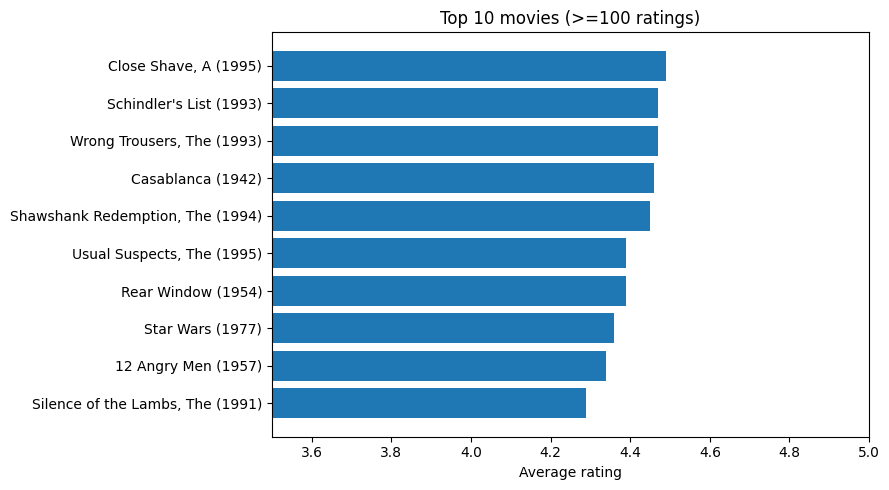

In [68]:
# Convert the Spark DataFrame to a Pandas DataFrame for plotting
pdf = val_top.orderBy("rank").toPandas()
plt.figure(figsize=(9,5)); plt.barh(pdf["title"][::-1], pdf["avg_rating"][::-1])
plt.xlabel("Average rating"); plt.xlim(3.5,5); plt.title("Top 10 movies (>=100 ratings)")
plt.tight_layout(); plt.show()

This bar chart represents visualizations from Task (ii). The top 10 movies (with at least 100 ratings) by average rating.

It shows the ten highest-rated wellrated films. It shows how tighlty clustered the bars are from each other. Every movie sits between 4.3 to 4.5 a span of only about 0.2 rating point. Star Wards the most-rated film at 583 ratings appears at 8th, while A Close Shave leads with just 112 ratings. This demonstrates that popularity and average quality are separate dimensions.

### 9.2 Distribution of Average Movie Ratings

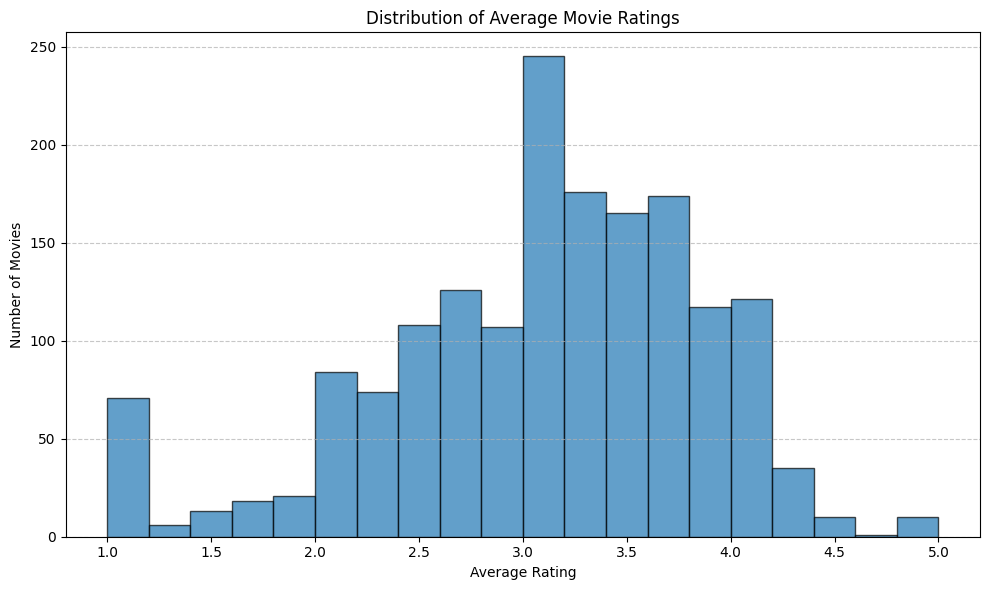

In [69]:
# Convert the Spark DataFrame to a Pandas DataFrame for plotting
pdf_movie_avg = movie_avg.toPandas()

plt.figure(figsize=(10, 6))
plt.hist(pdf_movie_avg['avg_rating'], bins=20, edgecolor='black', alpha=0.7)
plt.title('Distribution of Average Movie Ratings')
plt.xlabel('Average Rating')
plt.ylabel('Number of Movies')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

The histogram shows distribution of average ratings across all 1,682 movies. It is slightly left-skewed centered around 3.0-3.5. There are two anomalies at extreme ends, a spike at exactly 1.0  about 70 movies and a smaller one near 5.0 about 10 movies. A movie rated once or twice could land exactly at 1.0 or 5.0. These end-spikes are thinly-rated movies, where a single score determines whole average.

This chart only visually the >= 100 ratings threshold from Task (ii). The most extreme averages are least reliable. Hence, filtering by rating count removes them and leaves the turstworthy core of the distribution.

### 9.3 Favourite Genre

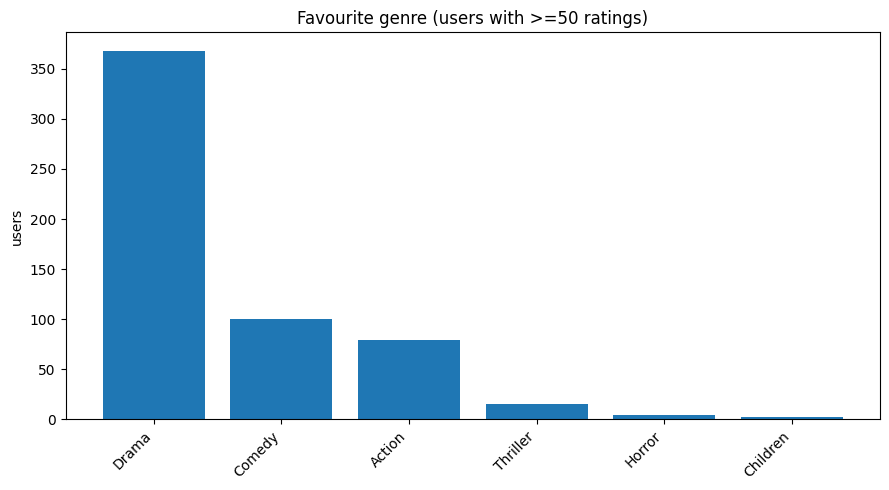

In [70]:
g = val_fav.groupBy("favourite_genre").count().orderBy(F.desc("count")).toPandas()
plt.figure(figsize=(9,5)); plt.bar(g["favourite_genre"], g["count"]); plt.xticks(rotation=45, ha="right")
plt.ylabel("users"); plt.title("Favourite genre (users with >=50 ratings)"); plt.tight_layout(); plt.show()

The bar chart shows favourite genre across all 568 active users (that rated at least 50 movies). The chart dominated by Drama as their favourite genre, followed by Comedy and Action. There's a small no. of users favoring Thriller, Horror and Children.

Drama is the most frequently assigned genre tag. A large share of movies have the Drama label, alongside other genres. This chart reflects catalogur composition and counting method more than personal preference. Each rating is counted once per genre a movie carries hence the most widely tagged genre wins by availability.



## 10. Interpretation & Discussion

**(i) Average rating per movie.** All 1,682 movies received at least one rating, with per-film averages spanning the full 1.0–5.0 scale around an overall mean of about **3.08**. The extremes are misleading in isolation: **141 movies were rated only once**, and each of the ten films showing a "perfect" 5.0 average had at most three ratings. Average rating alone therefore confounds quality with sample size  which is exactly why Task (ii) imposes a minimum-ratings threshold.

**(ii) Top ten movies.** Restricting to the **338 movies with ≥100 ratings**, the leaderboard is headed by *A Close Shave* (4.49), *Schindler's List* (4.47), *The Wrong Trousers* (4.47), *Casablanca* (4.46) and *The Shawshank Redemption* (4.45). All widely recognised, critically acclaimed titles rather than thinly-rated outliers. Notably, *Star Wars*, the single most-rated film (**583 ratings**), still places only 8th at 4.36: popularity and mean rating are related but not identical. This minimum rating requirement helps us discover excellent films that are genuinely well-regarded but might not be as widely known or popular, confirming that setting a baseline for popularity is a good approach for ranking.


**(iii) Favourite genre of active users.**  **568 are active** out of 943 users,(≥50 ratings). Their favourite genres are strikingly concentrated: **Drama accounts for 368 (≈65%)**, followed by Comedy (100) and Action (79), with only a thin tail of Thriller (15), Horror (4) and Children (2). This says less about individual taste than about **catalogue composition** . Drama is by far the most frequently assigned genre tag in `u.item`, so for most heavy raters it is mechanically their most-rated genre. A "favourite genre" derived from rating frequency reflects what is *available* to rate as much as genuine preference.

**(iv) Users under 20.** Only **77 of 943 users** are under 20 (ages 7–19), and **64 of them are students**. The audience skews older, and this young segment is both small and occupationally homogeneous, relevant to any age-targeted recommendation strategy.

**(v) Scientists aged 30–40.** **16 users** are scientists aged 30–40 (out of 31 scientists overall), all male except one. This is a deliberately narrow slice that demonstrates combining an equality filter (occupation) with a range filter (age) in Spark SQL.

**Pipeline validation.** Data was loaded into **HDFS** (`hdfs dfs -put`) and read back over `hdfs://` by Spark; the five result sets were written to **Cassandra** and read back, with row counts and samples matching the in-Spark results — confirming the full HDFS → Spark → Cassandra round-trip. The optional **MongoDB** section reproduces the top-ten ranking via an aggregation pipeline, giving the same result on a second NoSQL store.

# Optional Extension — Same tasks using MongoDB

This optional section persists the Spark results to **MongoDB** and also runs one
analytical task (top movies) natively with MongoDB's **aggregation pipeline**,
demonstrating the same analysis on a second NoSQL store. It runs after the required
pipeline.

## Mongo 1 — Install and start MongoDB

In [71]:
fast_get("mongodb-linux-x86_64-ubuntu2204-7.0.14.tgz", [
    "https://fastdl.mongodb.org/linux/mongodb-linux-x86_64-ubuntu2204-7.0.14.tgz"])
!tar -xzf mongodb-linux-x86_64-ubuntu2204-7.0.14.tgz

#install pymongo library
!pip install -q pymongo

MONGO = os.path.abspath("mongodb-linux-x86_64-ubuntu2204-7.0.14/bin")
os.makedirs("/content/mongodb-data", exist_ok=True)

#starts MongoDB as a background process
subprocess.Popen([MONGO + "/mongod", "--dbpath", "/content/mongodb-data",
                  "--bind_ip", "127.0.0.1"],
                 stdout=open("mongo.log", "w"), stderr=subprocess.STDOUT)
time.sleep(8)
print("MongoDB started (check mongo.log if the next cell can't connect)")

from cache: mongodb-linux-x86_64-ubuntu2204-7.0.14.tgz
MongoDB started (check mongo.log if the next cell can't connect)


## Mongo 2 — Connect and persist the Spark results

Each result DataFrame is collected and inserted into its own MongoDB collection
(the result sets are small, so a direct insert is simplest and robust).

In [72]:
#to connect to MongoDB databse from Python
from pymongo import MongoClient

#establishes a connection to MongoDB
client = MongoClient("mongodb://127.0.0.1:27017")

#select database
db = client["movielens"]

def to_mongo(df, coll):
    db[coll].drop()
    rows = [r.asDict() for r in df.collect()]
    if rows:
        db[coll].insert_many(rows)
    print(coll, "->", db[coll].count_documents({}), "docs")

# save sSpark DataFrame into a MongoDB collection
to_mongo(movie_avg, "movie_avg_ratings")
to_mongo(top_ten.select("rank","movie_id","title","avg_rating","num_ratings"), "top_ten_movies")
to_mongo(user_fav_genre, "user_fav_genre")
to_mongo(young_users, "young_users")
to_mongo(scientists, "scientists_30_40")

movie_avg_ratings -> 1682 docs
top_ten_movies -> 10 docs
user_fav_genre -> 568 docs
young_users -> 77 docs
scientists_30_40 -> 16 docs


## Mongo 3 — Run a task natively in MongoDB (aggregation pipeline)

To show MongoDB doing the analysis itself, we load the raw ratings into a
collection and reproduce **Task (ii)** — top ten movies with at least 100 ratings by
using MongoDB's aggregation framework (`$group`, `$match`, `$sort`, `$limit`).

In [73]:
# load raw ratings into MongoDB (from the local file downloaded in Setup 3)
db["ratings"].drop()
docs = []
with open("ml-100k/u.data") as f:
    for line in f:
        u, i, r, ts = line.split("\t")
        docs.append({"user_id": int(u), "item_id": int(i), "rating": int(r)})
db["ratings"].insert_many(docs)
print("ratings docs in MongoDB:", db["ratings"].count_documents({}))

# title lookup to show names, not just ids
# maps each movie_id to its corresponding title
titles = {row["movie_id"]: row["title"] for row in db["movie_avg_ratings"].find()}

# MongoDB aggregation pipeline
# each dictionaries represents an aggregation stage
# 1. groups the ratings by item_id
# 2. calculates the avg_rating for each item_id,
# 3. counts the num_ratings for each item_id
pipeline = [
    {"$group": {"_id": "$item_id",
                "avg_rating": {"$avg": "$rating"},
                "num_ratings": {"$sum": 1}}},
    {"$match": {"num_ratings": {"$gte": 100}}},  #filters the grouped results, with num_ratings greater than or equal to 100
    {"$sort": {"avg_rating": -1, "num_ratings": -1}},  #sorts the filtered movies in descending order of avg_rating, followed by num_ratings
    {"$limit": 10},  #limits the output to Top 10 results after sorting
]
print("\nTop 10 movies (MongoDB aggregation):")
for rank, d in enumerate(db["ratings"].aggregate(pipeline), 1):
    print(rank, titles.get(d["_id"], d["_id"]),
          round(d["avg_rating"], 3), int(d["num_ratings"]))

ratings docs in MongoDB: 100000

Top 10 movies (MongoDB aggregation):
1 Close Shave, A (1995) 4.491 112
2 Schindler's List (1993) 4.466 298
3 Wrong Trousers, The (1993) 4.466 118
4 Casablanca (1942) 4.457 243
5 Shawshank Redemption, The (1994) 4.445 283
6 Rear Window (1954) 4.388 209
7 Usual Suspects, The (1995) 4.386 267
8 Star Wars (1977) 4.358 583
9 12 Angry Men (1957) 4.344 125
10 Citizen Kane (1941) 4.293 198


## Mongo 4 — Validate

List the collections and read one document back to confirm the writes.

In [74]:
print("collections:", db.list_collection_names())
print("a scientist doc:", db["scientists_30_40"].find_one())
print("top movie doc :", db["top_ten_movies"].find_one(sort=[("rank", 1)]))

collections: ['ratings', 'top_ten_movies', 'scientists_30_40', 'movie_avg_ratings', 'user_fav_genre', 'young_users']
a scientist doc: {'_id': ObjectId('6a3d5c1745f6c0672b2404dc'), 'user_id': 538, 'age': 31, 'gender': 'M', 'occupation': 'scientist'}
top movie doc : {'_id': ObjectId('6a3d5c0f45f6c0672b24024d'), 'rank': 1, 'movie_id': 408, 'title': 'Close Shave, A (1995)', 'avg_rating': 4.49, 'num_ratings': 112}


## MongoDB — discussion

MongoDB stores each result as a document collection, with `find()` queries replacing
CQL/SQL. The aggregation pipeline reproduces the top-movies ranking entirely inside
MongoDB (`$group` -> `$match` -> `$sort` -> `$limit`), matching the Spark SQL result
and showing the same analysis is expressible across Spark, Cassandra and MongoDB.